Análise Exploratória de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/demanda_supermercado_2023_2024.csv")

# Tratamento de data e variáveis auxiliares

In [4]:
df["data"] = pd.to_datetime(df["data"])
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["mes_nome"] = df["data"].dt.strftime("%b")
df["dia_semana"] = df["data"].dt.day_name()

In [5]:
# Ordenação dos dias da semana
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
meses_ordenados = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

Volume de vendas por categoria

C:\Users\jessi\AppData\Local\Temp\ipykernel_6820\1570705345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


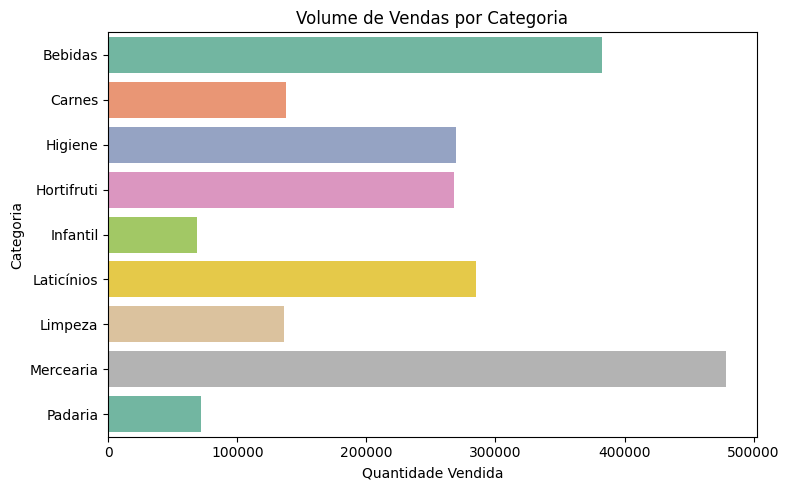

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df.groupby("categoria")["quantidade_vendida"].sum().reset_index(),
    x="quantidade_vendida",
    y="categoria",
    palette="Set2"
)
plt.title("Volume de Vendas por Categoria")
plt.xlabel("Quantidade Vendida")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

Produtos mais vendidos (Top 10)

C:\Users\jessi\AppData\Local\Temp\ipykernel_6820\2117261450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_produtos.values, y=top_produtos.index, palette="viridis")


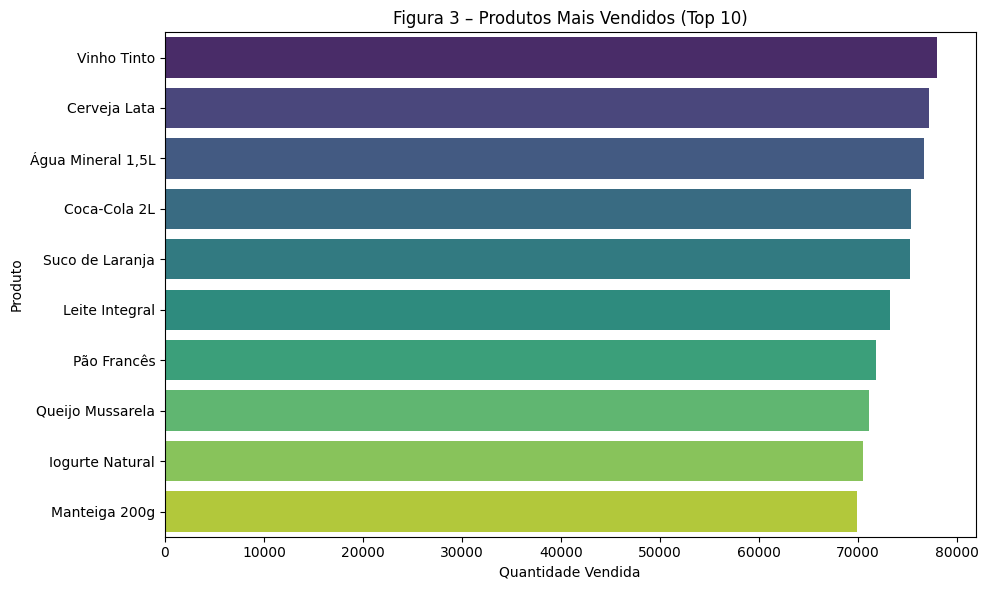

In [8]:
plt.figure(figsize=(10, 6))
top_produtos = df.groupby("produto")["quantidade_vendida"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_produtos.values, y=top_produtos.index, palette="viridis")
plt.title("Figura 3 – Produtos Mais Vendidos (Top 10)")
plt.xlabel("Quantidade Vendida")
plt.ylabel("Produto")
plt.tight_layout()
plt.show()

Evolução de vendas ao longo dos meses

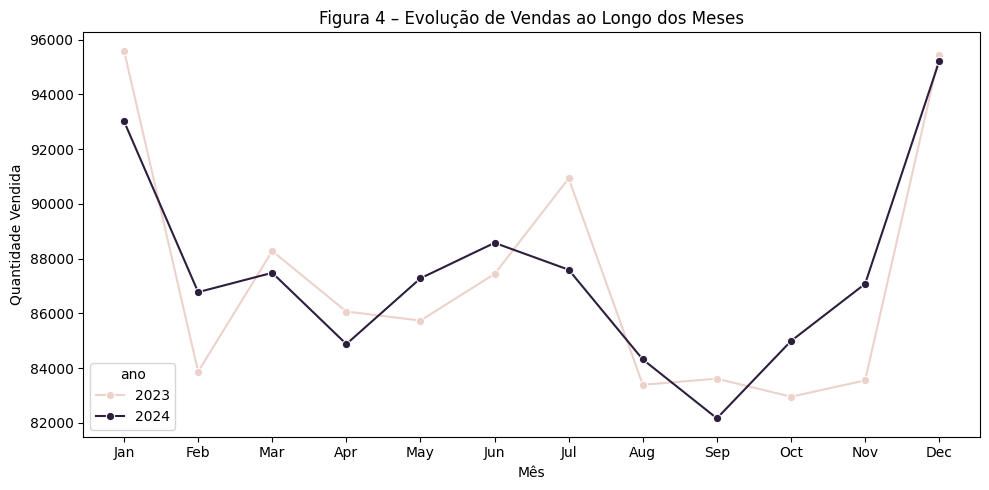

In [9]:
plt.figure(figsize=(10, 5))
df_mes = df.groupby(["ano", "mes_nome"])["quantidade_vendida"].sum().reset_index()
df_mes["mes_num"] = df_mes["mes_nome"].map({m: i for i, m in enumerate(meses_ordenados, 1)})
df_mes = df_mes.sort_values(by=["ano", "mes_num"])
sns.lineplot(data=df_mes, x="mes_nome", y="quantidade_vendida", hue="ano", marker="o")
plt.title("Figura 4 – Evolução de Vendas ao Longo dos Meses")
plt.xlabel("Mês")
plt.ylabel("Quantidade Vendida")
plt.tight_layout()
plt.show()

Vendas médias por dia da semana

C:\Users\jessi\AppData\Local\Temp\ipykernel_6820\1246789591.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_semana.index, y=df_semana.values, palette="pastel")


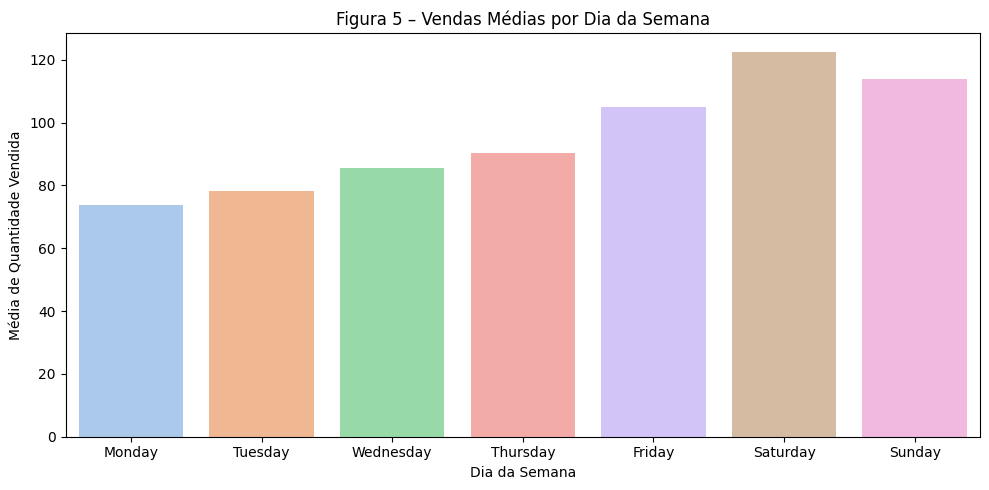

In [10]:
plt.figure(figsize=(10, 5))
df_semana = df.groupby("dia_semana")["quantidade_vendida"].mean().reindex(dias_ordenados)
sns.barplot(x=df_semana.index, y=df_semana.values, palette="pastel")
plt.title("Figura 5 – Vendas Médias por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Média de Quantidade Vendida")
plt.tight_layout()
plt.show()

Distribuição da quantidade vendida

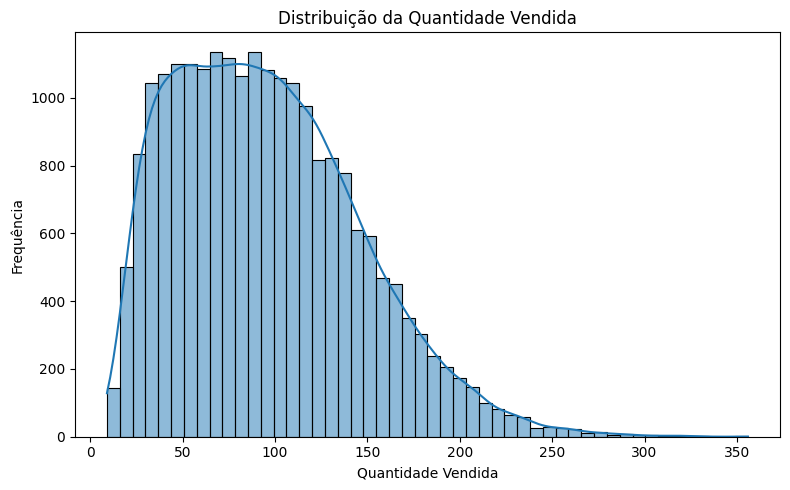

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["quantidade_vendida"], bins=50, kde=True)
plt.title("Distribuição da Quantidade Vendida")
plt.xlabel("Quantidade Vendida")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

Boxplot por categoria

C:\Users\jessi\AppData\Local\Temp\ipykernel_6820\3762782400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="categoria", y="quantidade_vendida", palette="Set3")


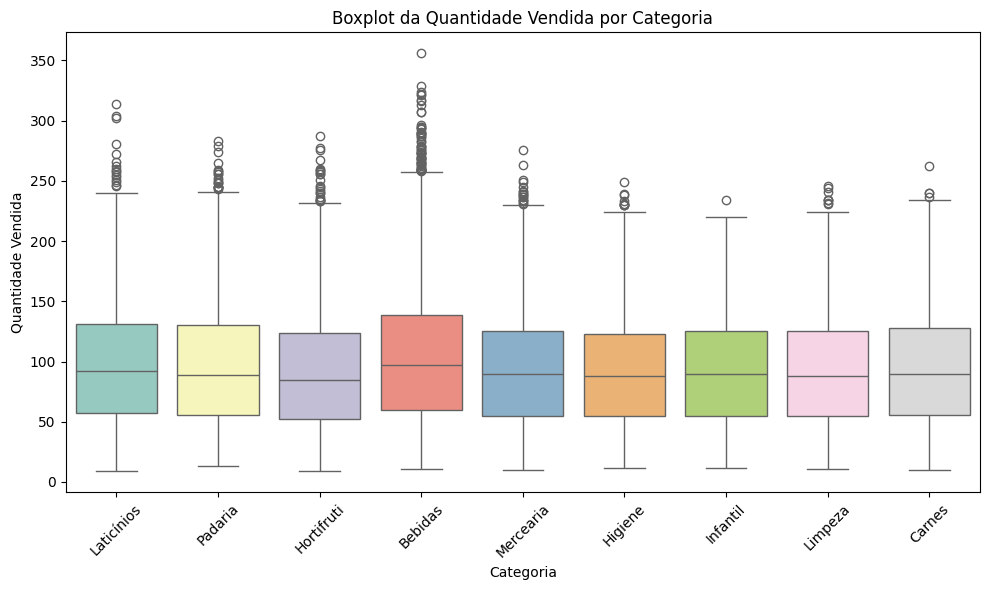

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="categoria", y="quantidade_vendida", palette="Set3")
plt.title("Boxplot da Quantidade Vendida por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Tendência semanal por categoria

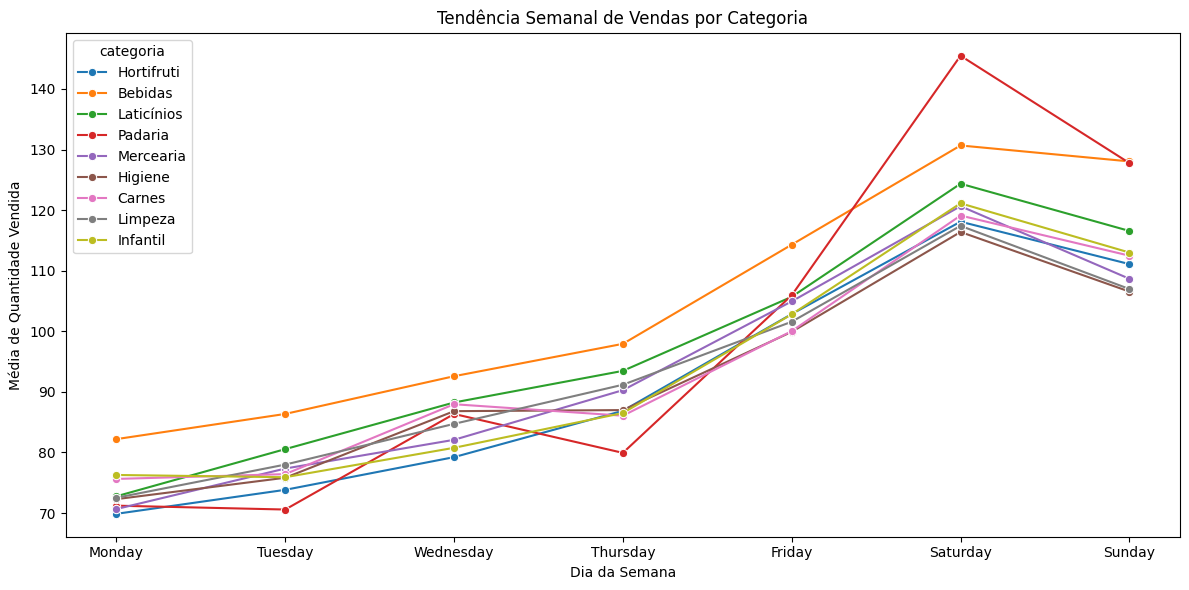

In [13]:
plt.figure(figsize=(12, 6))
df_semana_cat = df.groupby(["categoria", "dia_semana"])["quantidade_vendida"].mean().reset_index()
df_semana_cat["dia_semana"] = pd.Categorical(df_semana_cat["dia_semana"], categories=dias_ordenados, ordered=True)
df_semana_cat = df_semana_cat.sort_values(by="dia_semana")
sns.lineplot(data=df_semana_cat, x="dia_semana", y="quantidade_vendida", hue="categoria", marker="o")
plt.title("Tendência Semanal de Vendas por Categoria")
plt.xlabel("Dia da Semana")
plt.ylabel("Média de Quantidade Vendida")
plt.tight_layout()
plt.show()